# Lista 02 de Visão Computacional

Beatriz Rodrigues Cavalcante - 22210505

Hugo Coêlho da Silva - 22111533

Link da lista: https://drive.google.com/file/d/1T3TA4E8gkh4GZb2wwRoXcXnGqmisrElr/view


## Importações e Funções Auxiliares


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from cv2.typing import MatLike
from pathlib import Path


def show_images(
    *images: np.ndarray,
    titles: list[str] | None = None,
    columns: int = 2,
    scale: int = 5,
) -> None:
    num_images = len(images)

    if titles is None:
        titles = [f"Image {i + 1}" for i in range(num_images)]

    rows = (num_images + columns - 1) // columns

    fig, axes = plt.subplots(rows, columns, figsize=(scale * columns, scale * rows))
    axes = np.array(axes).reshape(rows, columns)

    for ax, img, title in zip(axes.flat, images, titles):
        ax.imshow(img, cmap="gray" if len(img.shape) == 2 else None)
        ax.set_title(title)

    for i in range(num_images, rows * columns):
        fig.delaxes(axes.flat[i])

    plt.tight_layout()

## Questão 1

Nesta questão, foi experimentado três detectores de quinas diferentes: [`Harris Corner Detection`](https://www.datatechnotes.com/2023/07/harris-corner-detection-example-with.html), [`Shi-Thomas Corner Detector`](https://docs.opencv.org/4.5.3/d4/d8c/tutorial_py_shi_tomasi.html) e [`FAST Algorithm`](https://docs.opencv.org/4.5.3/df/d0c/tutorial_py_fast.html).


### Harris Corner Detector

A ideia desse detector é encontrar a variação de intensidade no deslocamento de uma janela centrada num ponto $(u,v)$ em todas as direções, visto que em bordas a variação é forte em apenas uma direção, enquanto em quinas é forte em várias. O fluxo do detector é iniciado pela aplicação, opcional, de uma suavização para diminuir os ruídos; depois, é usado o operador de Sobel para captar as mudanças de intensidade horizontais e verticais em cada pixel; e então, utilizando os gradientes, é analisado a variação da intensidade em vizinhanças locais olhando para os autovalores ($\lambda_1$ e $\lambda_2$), onde temos que:

- $\lambda_1 \approx 0, \lambda_2 \approx 0$ são regiões planas, onde não há mudança significativa em nenhuma direção.
- $\lambda_1 \gg 0, \lambda_2 \approx 0$ são bordas, onde há uma mudança forte em apenas uma direção, mas nenhuma na direção perpendicular.
- $\lambda_1 \gg 0, \lambda_2 \gg 0$ são quinas, onde há mudanças fortes em múltiplas direções.

Então, uma pontuação é atribuída a cada janela para determinar se é uma quina ou não: $$R = \lambda_1\lambda_2 − k(\lambda_1 + \lambda_2)^2$$

No algoritmo, os parâmetros principais são:

- _img_: a imagem a ser analizada em tons de cinza.
- _blockSize_: tamanho da vizinhança.
- _ksize_: tamanho do Sobel para gradiente.
- _k_: sensibilidade do critério Harris.

### Shi-Tomasi Corner Detector (Good Features to Track)

Shi-Tomasi é uma melhoria do Harris Detector. Os autores perceberam que somente quando o $\lambda_1$ e $\lambda_2$ são maiores que um treshold $\lambda_{min}$ é considerado uma quina, então eles propuseram que o cálculo da pontuação fosse simplesmente: $$R = \min(\lambda_1, \lambda_2)$$. E a ideia intuitiva desse método é que se queremos que um ponto seja uma quina, ele precisa ter variações fortes em todas as direções. Isso significa que tanto $\lambda_1$ quanto $\lambda_2$ devem ser grandes. Se o menor deles ($\min$) já for maior que um determinado threshold, então o maior com certeza também é.

No algoritmo, temos os seguintes parâmetros:

- _img_: a imagem a ser analizada em tons de cinza.
- _maxCorners_: máximo de cantos retornados. Se houver mais cantos do que os encontrados, o mais forte deles será retornado. No entanto, se `maxCorners <= 0` implica que nenhum limite máximo foi definido e todos os cantos detectados serão retornados.
- _qualityLevel_: qualidade mínima relativa. O valor do parâmetro é multiplicado pela melhor pontuação, seja ele o menor autovalor ou a resposta da função de Harris. Os cantos com medida de qualidade inferior ao produto são rejeitados. Por exemplo, se o melhor canto tiver medida de qualidade = 1500 e qualityLevel = 0,01, então todos os cantos com medida de qualidade inferior a 15 serão rejeitados.
- _minDistance_: distância mínima entre pontos, para evitar pontos colados.

### FAST Algorithm (Features from Accelerated Segment Test)

Esse algoritmo tem como principio ser, como o nome indica, mais rápido do que preciso, para aplicações em tempo real (drones, robótica, AR). FAST usa um circulo de Bresenham de raio $r=3$, ou seja com 16 pixels, para classificar qual ponto $P$ é de fato uma quina. Para isso, deve haver um arco de $n$ pixels consecutivos, onde ou todos são siginificamente mais brilhantes ou signigicativamente mais escuros que $P$. A grande sacada do FAST é fazer um teste de descarte precoce, ele não testa os 16 pixeis, ele primeiro olha os quatro pontos cardeais (os pixeis 1, 8, 5, 13). Para afirmar que $P$ é uma quina, três desses quatros pixels cardeais devem ser muito mais claros ou muito mais escuros que $P$. Se não forem, o algoritmo já descarta e vai pro próximo. Para deixar mais rápido ainda, os criadores do FAST usaram Machine Learning para treinar o algoritmo sobre quais pixels são mais prováveis de serem quinas.

No algoritmo, temos os seguintes parâmetros:

- _threshold_: define a intensidade para a seleção das quinas.
- _nonmaxSuppression_: serve para evitar aglomerados de pontos no mesmo lugar, visto que o detector pode identificar pixeis próximos da quina como quina também.
- _type_: são os parâmetros do FAST, o $r$ e o $n$.
  - `TYPE_9_16`: Usa um círculo de 16 pixels e precisa de 9 pixels consecutivos. É o que usa a otimização por Machine Learning.
  - `TYPE_7_12`: Usa um círculo de 12 pixels e precisa de 7 consecutivos. É mais rápido, mas menos robusto.
  - `TYPE_5_8`: Usa um círculo de 8 pixels e precisa de 5 consecutivos. É o modo ultra-rápido para imagens muito pequenas ou hardware muito limitado.


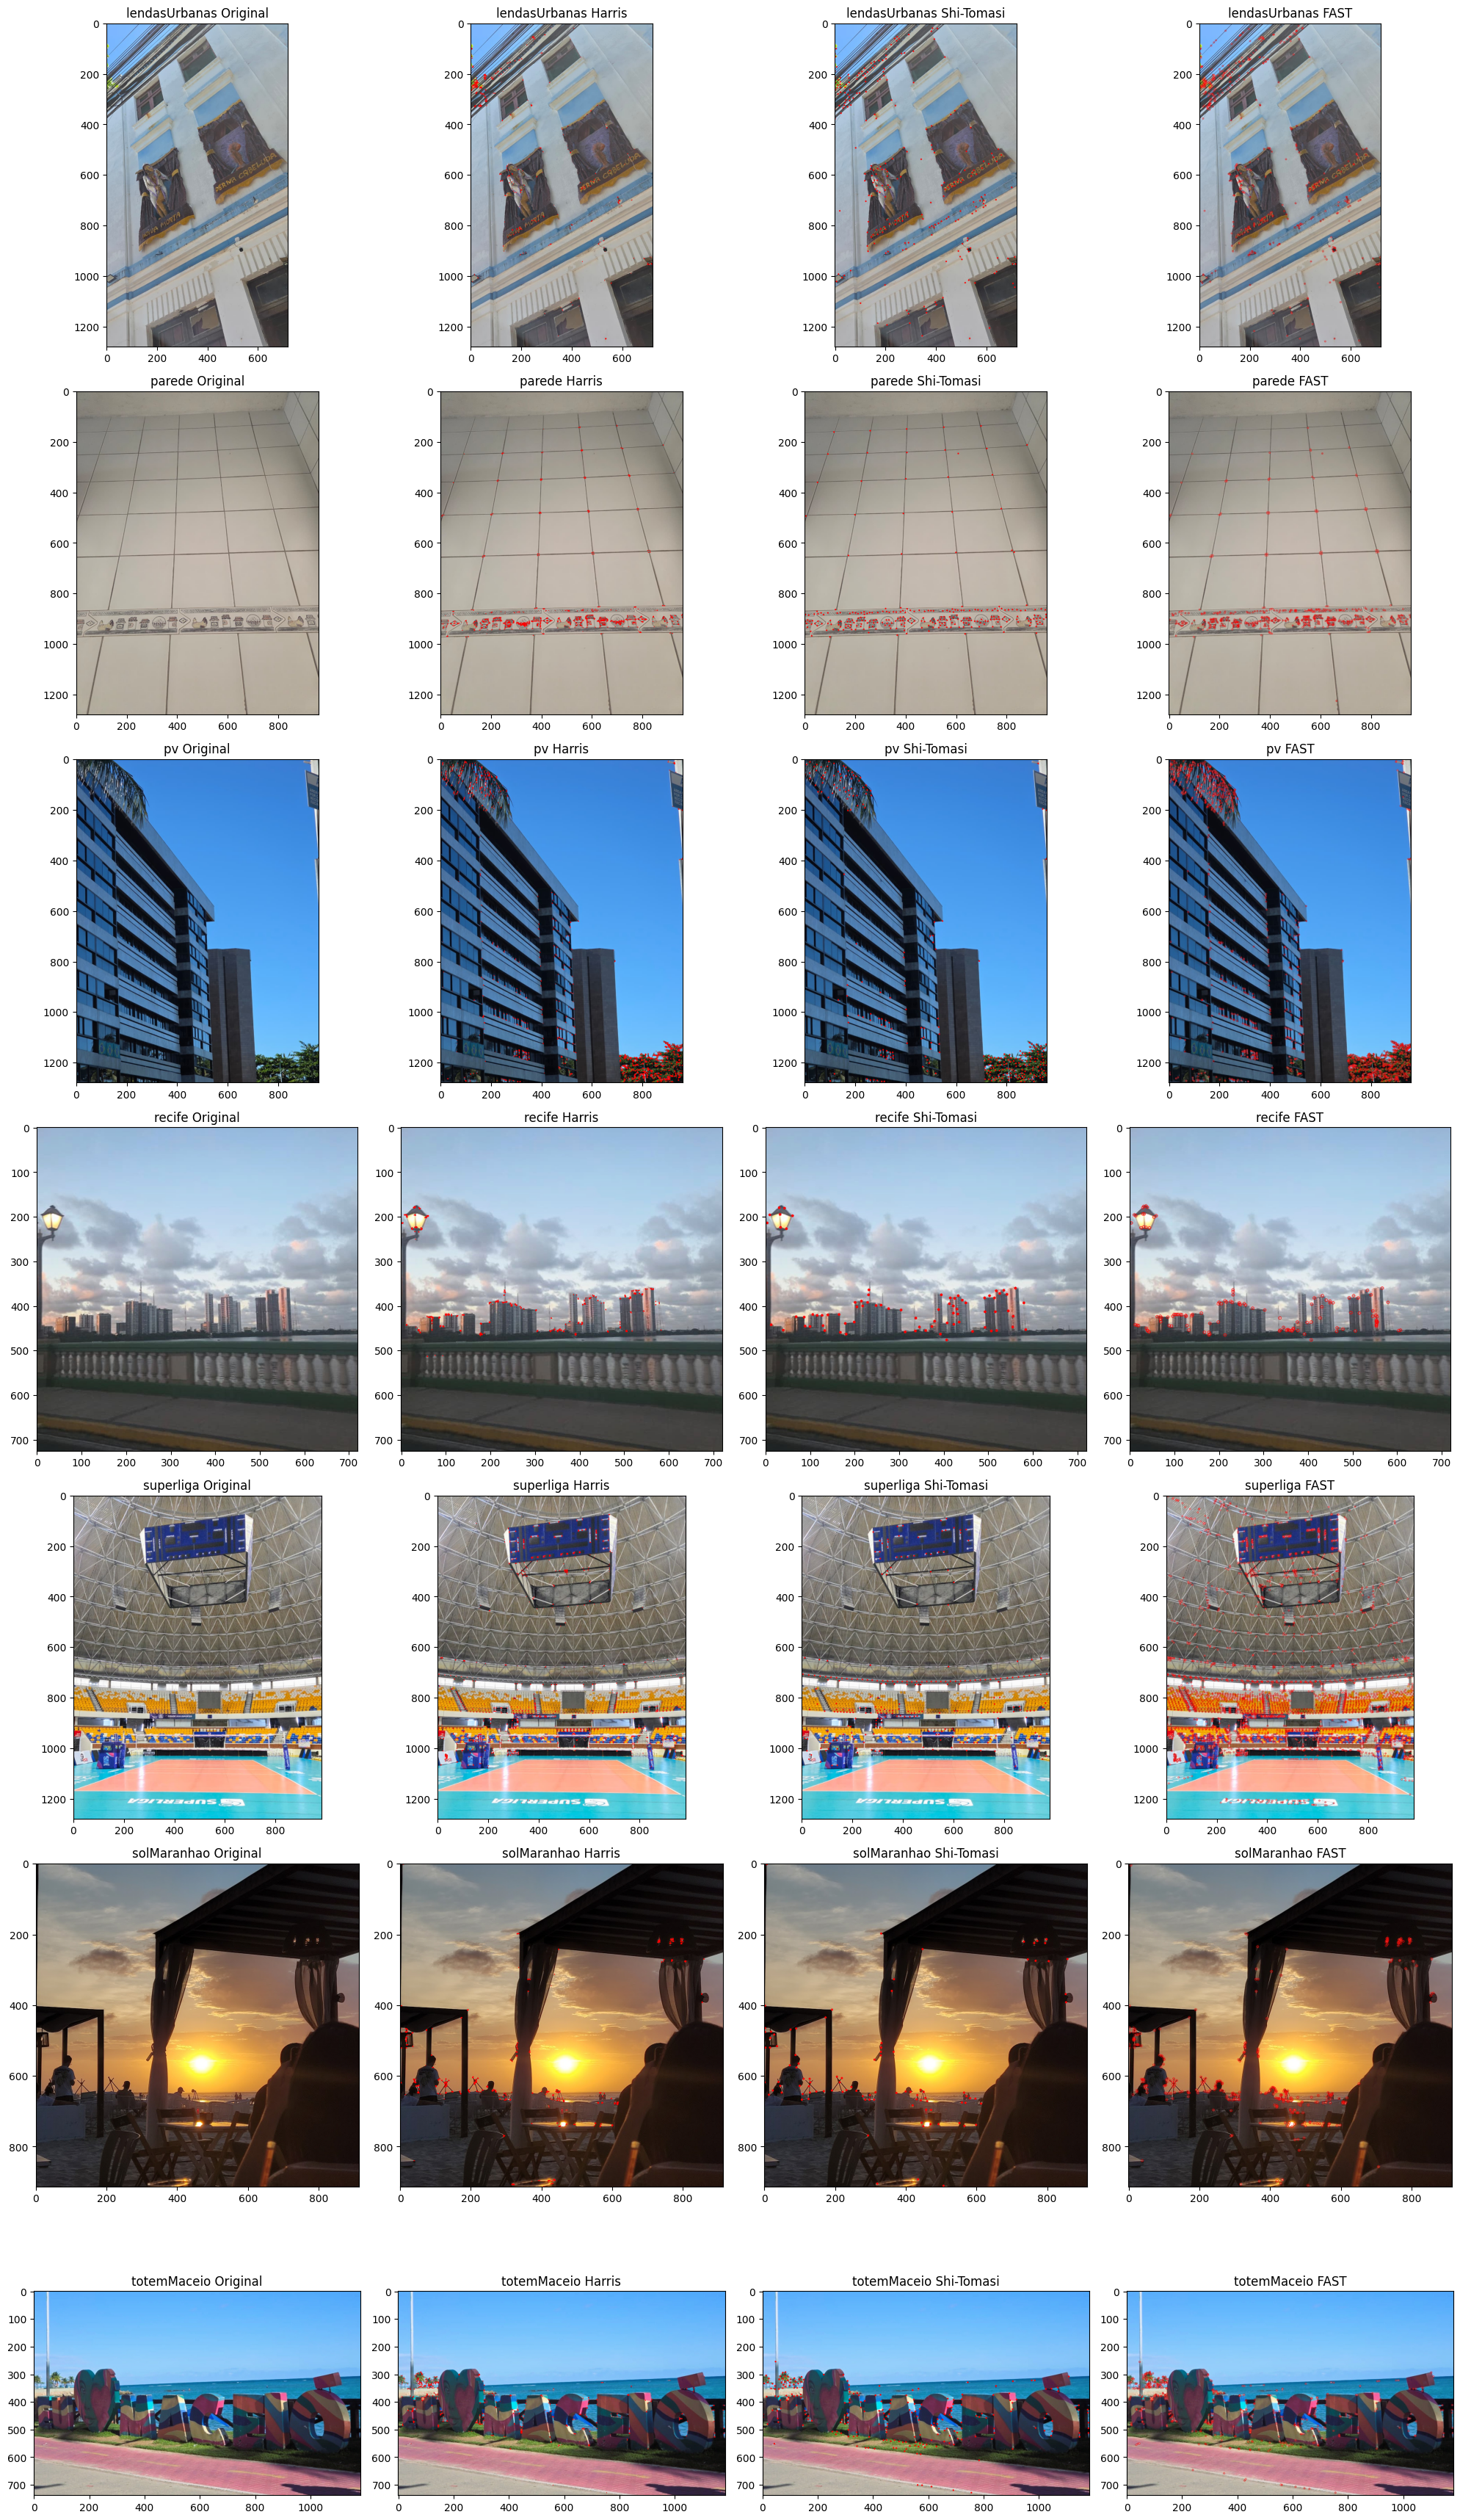

In [3]:
# https://www.datatechnotes.com/2023/07/harris-corner-detection-example-with.html
# https://docs.opencv.org/4.5.3/d4/d8c/tutorial_py_shi_tomasi.html
# https://docs.opencv.org/4.5.3/df/d0c/tutorial_py_fast.html
# https://en.wikipedia.org/wiki/Features_from_accelerated_segment_test


def harris_operator(img: MatLike, blockSize=3, ksize=3, k=0.06) -> MatLike:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    gray = cv.GaussianBlur(gray, (5, 5), 0)

    harris_corners = cv.cornerHarris(gray, blockSize, ksize, k)
    kernel = cv.getStructuringElement(cv.MORPH_RECT, (2, 2))
    harris_corners = cv.dilate(harris_corners, kernel)

    threshold = 0.02 * harris_corners.max()
    corner_img = np.copy(img)

    corner_img[harris_corners > threshold] = [0, 0, 255]
    return corner_img


def shiTomasi_operator(img: MatLike) -> MatLike:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    corner_img = np.copy(img)

    corners = cv.goodFeaturesToTrack(gray, 270, 0.1, 10)
    if corners is not None:
        corners = corners.astype(np.int32)
        for i in corners:
            x, y = i.ravel()
            cv.circle(corner_img, (x, y), 3, (0, 0, 255), -1)

    return corner_img


def fast_detector(img: MatLike) -> MatLike:
    fast = cv.FastFeatureDetector.create(
        threshold=50,
        nonmaxSuppression=True,
        type=cv.FAST_FEATURE_DETECTOR_TYPE_9_16,
    )
    keypoints = fast.detect(img, None)
    corner_img = cv.drawKeypoints(img, keypoints, np.copy(img), color=(0, 0, 255))

    return corner_img


# def sift_detector(img: MatLike) -> MatLike:
#     gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#     sift = cv.SIFT.create()
#     kp = sift.detect(gray, None)
#     corner_img = cv.drawKeypoints(img, kp, np.copy(img), flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

#     return corner_img


filenames = [
    "images/lendasUrbanas.jpeg",
    "images/parede.jpeg",
    "images/pv.jpeg",
    "images/recife.jpeg",
    "images/superliga.jpeg",
    "images/solMaranhao.jpg",
    "images/totemMaceio.jpeg",
]
comparison_images = []
comparison_titles = []

for filename in filenames:
    img = cv.imread(filename)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {filename}")

    img_name = Path(filename).stem
    original = cv.cvtColor(np.copy(img), cv.COLOR_BGR2RGB)
    harris = cv.cvtColor(harris_operator(img), cv.COLOR_BGR2RGB)
    shi_tomasi = cv.cvtColor(shiTomasi_operator(img), cv.COLOR_BGR2RGB)
    fast = cv.cvtColor(fast_detector(img), cv.COLOR_BGR2RGB)

    comparison_images.extend([original, harris, shi_tomasi, fast])
    comparison_titles.extend(
        [
            f"{img_name} Original",
            f"{img_name} Harris",
            f"{img_name} Shi-Tomasi",
            f"{img_name} FAST",
        ]
    )

show_images(*comparison_images, titles=comparison_titles, columns=4, scale=5)

Foram testadas 7 imagens capturadas por celular, comparando três detectores de quina: **Harris**, **Shi-Tomasi** e **FAST**. Em todos os casos, foram utilizados os mesmos parâmetros entre as imagens, a escolha foi voltada à redução de falsos positivos, especialmente em regiões com textura repetitiva e ruído, em todas as imagens. Como as imagens foram obtidas por celular, variações de qualidade também podem ter influenciado a detecção de quinas.

Visualmente, o **Harris** apresentou bom desempenho em cantos bem definidos e com alto contraste (como em `solMaranhao`), mas teve pior resultado em áreas muito texturizadas, onde tende a marcar pontos em excesso (por exemplo, em plantas e padrões de azulejo).

O **Shi-Tomasi** mostrou resultados mais estáveis na seleção de cantos relevantes, sem aquele aglomerado de pontos querendo representar a mesma quina. Em algumas imagens, ele perdeu alguns pontos interessantes, que os outros algoritmos trazem, e em outras ele trouxe falsos positivos, onde dá mais pra ver na imagem `totemMaceio`, onde ele sugere pontos na borda da ciclovia e na região ruidosa da grama. Entre os três é o mais equilibrado.

Já o **FAST** foi o mais sensível a ruído e variações de iluminação, gerando detecções inadequadas, gerando uma densidade consideravelmente maior que a do próprio detector de Harris. Por isso, foi necessário aumentar o `threshold` para melhorar sua robustez. Ele também apresenta muitos pontos aglomerados pra indicar a mesma quina, mesmo com o parâmetro _nonmaxSuppression_ ativo.


## Questão 2

Nesta questão, foi experimentado três descritores diferentes: `SIFT`, `ORB` e `BRISK`. Usando `BFMatcher` para geração das correspondências.


### [SIFT (Scale-Invariant Feature Transform)](https://docs.opencv.org/4.5.3/d7/d60/classcv_1_1SIFT.html)

O detector de Harris é invariante a rotação, o que faz sentido visto que uma quina vai ser uma quina independente da sua rotação, mas a história é diferente em relação a escala, pra isso SIFT foi criado.

Este algoritmo aplica vários níveis de desforque guassiano ($\sigma$) na imagem e as subtrai, esta técnica é chamada de **difference of gaussians**. Se um ponto for identificado como máximo em várias escalas diferentes, ele é marcado como ponto interessante. Então, ele faz uma filtragem nesses pontos interessantes, removendo aqueles com baixo contraste e pontos nas bordas, e ficando com os mais pontos mais fortes. Para cada um desses pontos fortes, o SIFT analisa a magnitude e a direção do gradiente ao redor dele e é criado um histograma, os picos mais altos no histograma são considerados para calcular a orientação. Agora, ele monta o descritor, pega uma vizinhança de 16x16 pixels ao redor do ponto e a divide em blocos menores de 4x4. Para cada bloco, ele cria um histograma de 8 direções de gradiente.

No algoritmo do OpenCV, temos os seguintes parâmetros:
- *nfeatures*: O número de melhores features que vão ser retornadas.
- *nOctaveLayers* O número de camadas de vizinhos a serem analisados. O número de camadas é computado automaticamente pela resolução da imagem.
- *contrastThreshold*: Serve como um thresold para filtrar as features com baixo contraste. Quanto maior, menos features são produzidas pelo detector.
- *edgeThreshold*: O threshold usado para filtrar as features parecidas com as bordas. Quanto maior o threshold, mais features são mantidas.
- *sigma*: O sigma da gaussiana aplicada na camada #0.


### [ORB (Oriented FAST and Rotated BRIEF)](https://docs.opencv.org/4.5.3/d1/d89/tutorial_py_orb.html)
O ORB é uma mistura do detector FAST com o descritor BRIEF acrescentando melhorias.

Ele usa o FAST para encontrar os pontos de interesse, mas como o FAST encontra muitos pontos, então aplica o operador de Harris para encontrar os $N$ pontos mais relevantes entre eles. E ai, cria uma pirâmide de oitavas com versões menores da imagem, para garantir a invariância de escala. Agora, para garantir a invariância de rotação, o ORB calcula um centro de massas dos pixels ao redor do ponto e desenha um vetor do centro do ponto até o centro da massa, o ângulo desse bvetor é a orientação do ponto. Depois de achar o ponto, o algoritmo usa o BRIEF melhorado para gerar o descritor daquele ponto. O BRIEF original é muito ruim com rotação, então o ORB direciona o BRIEF de acordo com as orientações dos pontos de interesse.

No algoritmo, temos como principais parâmetros:
- *nfeatures*: O número máximos de features a serem retornadas.
- *scaleFactor*: Influencia na geração da pirâmide de escala. Quanto maior o valor, maior a robustez em relação à escala, mas maior o custo computacional.
- *nlevels*: A quantidade de camadas das pirâmide.


### BRISK (Binary Robust Invariant Scalable Keypoints)
O BRISK é um algoritmo que busca o equilíbrio entre a precisão do SIFT e a velocidade do ORB. 

Assim como em outros descritores, ele utiliza a pirâmide de oitavas, mas o diferencial dele é que ele também analisa as camadas intermediárias entre essas reduções, garantindo que nenhum detalhe se perca quando o tamanho do objeto muda. A detecção de pontos de interesse no BRISK utiliza uma versão aprimorada do algoritmo FAST, onde ele faz a detecção de quinas olhando todas as camadas da pirâmide.

Mas o destaque o BRISK é o descritor binário dele. Ele organiza o compara o brilho de pares de pontos específicos organizados em círculos concêntricos ao redor da quina: os pares de longa distância são usados para definir a orientação do ponto, enquanto os pares de curta distância realizam comparações de intensidade.


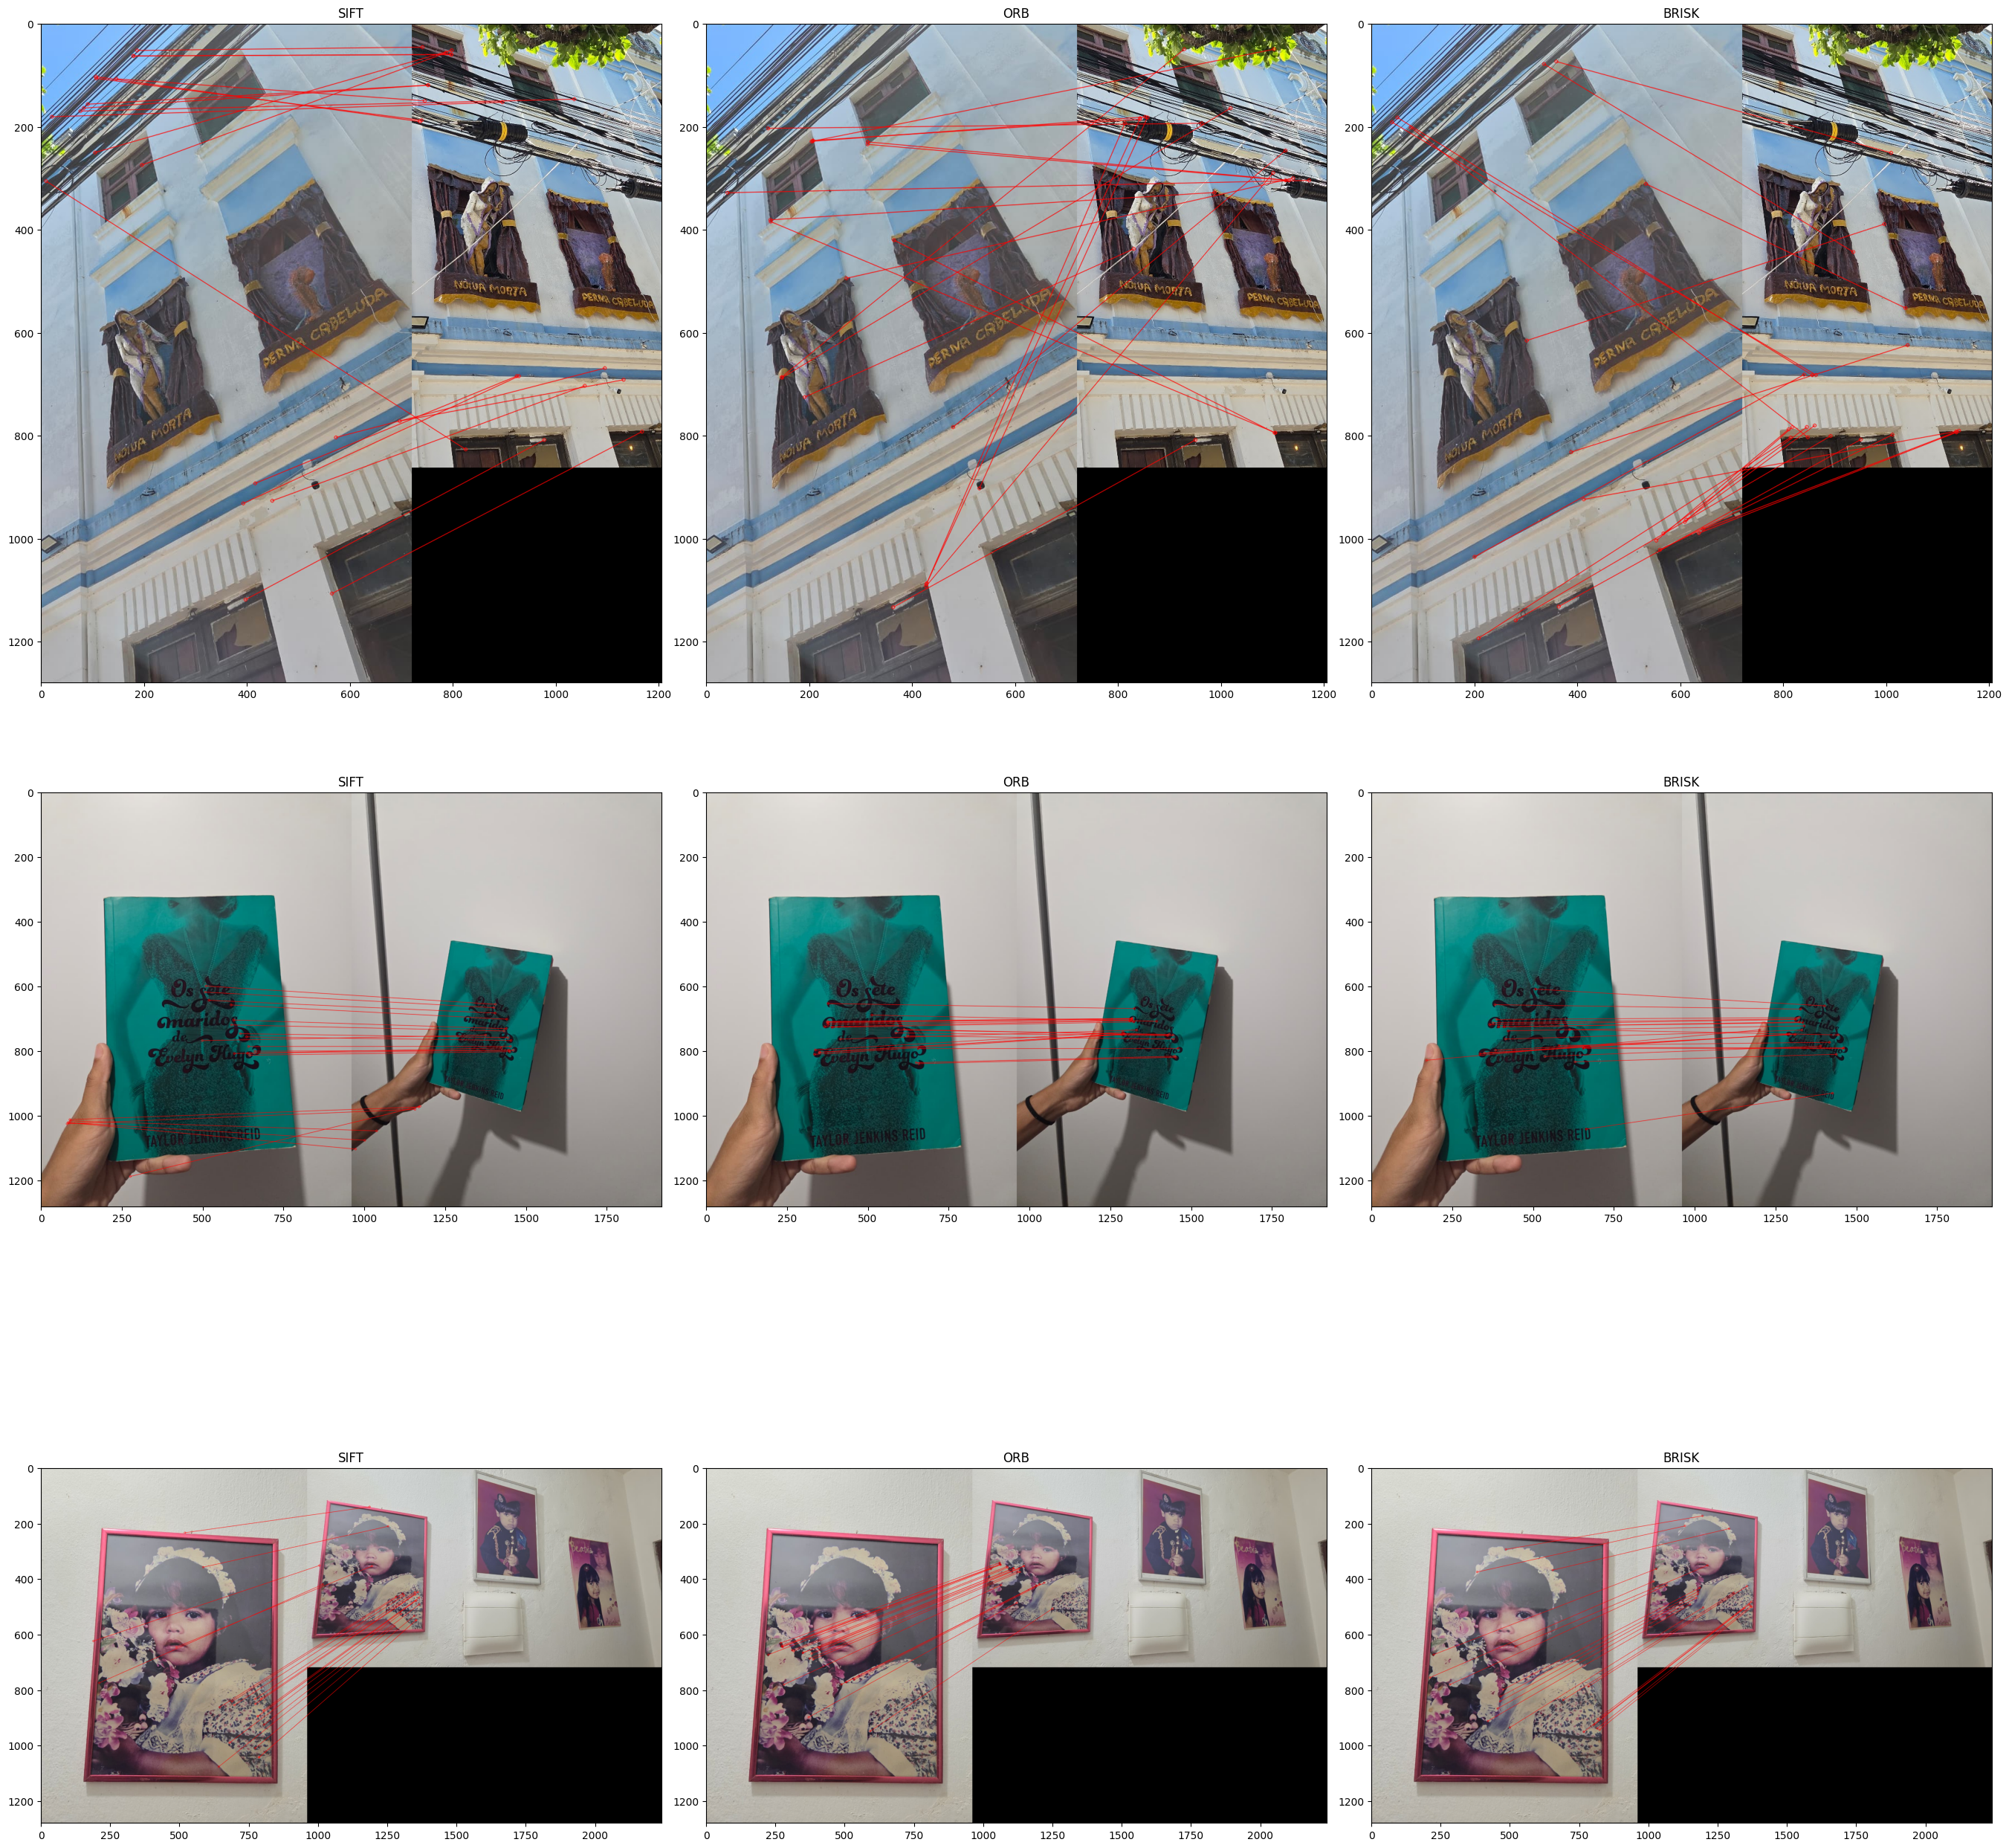

In [24]:
def match_images(img1: MatLike, img2: MatLike, descriptor_type: str = "sift") -> MatLike:
    descriptor_type = descriptor_type.lower()

    if descriptor_type == "sift":
        detector = cv.SIFT.create()
        norm_type = cv.NORM_L2
    elif descriptor_type == "orb":
        detector = cv.ORB.create()
        norm_type = cv.NORM_HAMMING
    elif descriptor_type == "brisk":
        detector = cv.BRISK.create()
        norm_type = cv.NORM_HAMMING
    else:
        raise ValueError(f"Tipo de descritor '{descriptor_type}' não suportado. Use: sift, orb, akaze")

    kp1, des1 = detector.detectAndCompute(img1, None)
    kp2, des2 = detector.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        raise ValueError(f"O descritor '{descriptor_type}' não encontrou features suficientes nas imagens.")

    bf = cv.BFMatcher(norm_type, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    out_img = np.zeros((max(img1.shape[0], img2.shape[0]), img1.shape[1] + img2.shape[1], 3), dtype=np.uint8)

    img_matched = cv.drawMatches(
        img1, kp1,
        img2, kp2,
        matches[:20],
        out_img,
        flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
        matchColor=(0, 0, 255),
    )

    return img_matched


descriptors = ["SIFT", "ORB", "BRISK"]
filenames = [
    ("images/lendasUrbanas.jpeg", "images/lendasUrbanas2.jpg"),
    ("images/evelynHugo.jpeg", "images/evelynHugo2.jpeg"),
    ("images/poster.jpeg", "images/poster2.jpeg"),
]
comparison_images = []
comparison_titles = []

for filename1, filename2 in filenames:
    img1 = cv.imread(filename1)
    img2 = cv.imread(filename2)
    if img1 is None or img2 is None:
        raise FileNotFoundError(f"Could not load images {filename1} or {filename2}")

    for descriptor in descriptors:
        result = match_images(img1, img2, descriptor)
        result = cv.cvtColor(result, cv.COLOR_BGR2RGB)
        comparison_images.append(result)
        comparison_titles.append(descriptor)

show_images(*comparison_images, titles=comparison_titles, columns=3, scale=9)

Foram testados 3 pares de imagens com os descritores **SIFT**, **ORB** e **BRISK**, usando `BFMatcher` com `crossCheck=True` e exibindo os 20 melhores matches por distância.

- **Par 1 (fachada):** há mudança de perspectiva e regiões repetitivas. É a foto mais díficil. E nesse caso, os três métodos geraram alguns matches incorretos. O **SIFT** foi o que trouxe resultados mais adequados, enquanto **ORB** e **BRISK** retornaram mais pares, mas com maior presença de outliers em áreas de textura repetida. Como o **ORB** mapeando as quinas da porta como a fiação do poste, e o **BRISK** mapeando a parte superior da janela com a figura, como sendo a parte inferior, onde contém o nome da peça.

- **Par 2 (livro):** o objeto possui bordas fortes e texto bem definido, as fotos possuem uma rotação e uma leve mudança de pespectiva. Os três descritores funcionaram bem. O **ORB** e o **BRISK** geraram mais matches concentrados na tipografia e nas bordas do livro, e o **SIFT** foi o único que se arriscou em dar match entre as mãos, trazendo outliers para estes matches.

- **Par 3 (pôster):** A primeira foto é uma foto centrada do pôster, enqunato a segunda foto possui mais objetos e em uma rotação + pespectiva diferente. O **ORB** se manteve estável, mas trouxe os matches apenas numa região pequena e especifica do pôster principal, enquanto o **SIFT/BRISK** apresentaram maior quantidade de matches em diversas partes do pôster.


## Questão 3

Nesta questão, foi desenvolvido um algoritmo para identificação de produtos.

https://docs.opencv.org/4.5.3/d1/de0/tutorial_py_feature_homography.html


## Questão 4

Nesta questão, foi 
